# Praktika: Sare Neuronala

Praktika honetarako smart erlojuek neurtutako datuen arabera, pertsonen estres-maila aztertzen duen datu-bilduma jorratuko duzue. Horretarako [datu-bilduma hau](https://drive.google.com/file/d/12MhpFIyD8MoTgCOmHI9BKWlT1bi7LY6d/view?usp=sharing) erabiliko da. Hainbat aldagai azaltzen dira, hauen artean; bihotz taupadak, azalaren tenperatura edota jarduera fisiko maila.

Era berean, datu-bilduma honen klasea `label` zutabea da. Rested eta stressed aldagaiekin.

## 0. Ariketa: Prestaketak

In [236]:
## importak
###########
## pytorch
import torch
import torch.nn as nn
import torch.optim as optim

## sklearn, numpy, mpl, pandas, seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import seaborn as sns

# grafikoen aurrekonfigurazioa
plt.style.use('seaborn-v0_8-whitegrid')

## CUDA?
print(f"PyTorch bertsioa: {torch.__version__}")
print(f"GPU erabilgai?: {torch.cuda.is_available()}")

# seed-ak ezarri
np.random.seed(42)
torch.manual_seed(42)

PyTorch bertsioa: 2.10.0+cpu
GPU erabilgai?: False


In [237]:
## datu bilduma kargatu
df = pd.read_csv('stress_sequences.csv')
df.tail()

,sequence_id,timestep,heart_rate_bpm,hrv_ms,blood_oxygen_pct,accel_g,resp_rate_bpm,skin_temp_c,gsr_microsiemens,noise_db,steps_per_min,sleep_debt_hours,activity_level,noise_environment,skin_temp_profile,gsr_state,label
11515,239,43,95.62,37.89,93.06,1.005,19.98,36.00,7.44,56.30,65,4.16,active,busy,cool,overstimulated,stressed
11516,239,44,92.39,43.03,93.56,0.534,18.84,36.05,8.33,55.64,62,4.16,active,busy,cool,overstimulated,stressed
11517,239,45,94.16,39.45,93.51,0.743,20.07,36.05,7.78,53.62,53,4.16,active,busy,cool,overstimulated,stressed
11518,239,46,98.21,41.24,92.77,0.701,19.81,36.02,8.04,61.10,53,4.16,active,loud,cool,overstimulated,stressed
11519,239,47,96.46,35.95,93.37,0.917,20.32,35.93,7.80,59.12,57,4.16,active,busy,cool,overstimulated,stressed


label
rested      9216
stressed    2304
Name: count, dtype: int64


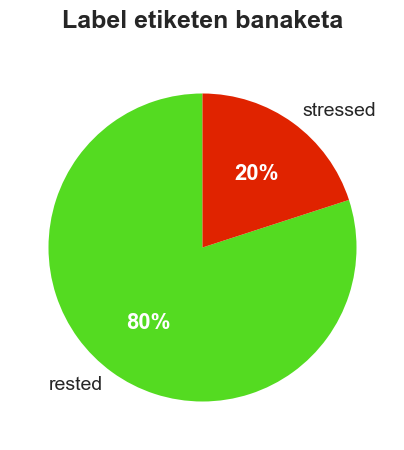

In [238]:
## label etiketen banaketa diagrama (pie chart)

label_counts = df['label'].value_counts()
print(label_counts)

# pie chart sortu
fig, ax = plt.subplots(figsize=(5, 5))

# koloreak
colors = ['#54DB21', '#E02300'] 

# grafikoa konfiguratu
wedges, texts, autotexts = ax.pie(
    label_counts.values, 
    labels=label_counts.index,
    autopct='%.0f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 14}
)

# Barruko ehunekoak
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(16)

ax.set_title('Label etiketen banaketa', fontsize=18, fontweight='bold', pad=20)

plt.show()
fig.savefig(fname='irudiak/pie_chart_label.pdf', format='pdf', dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')


In [239]:
## one hot encoding

one_hot_labels = pd.get_dummies(df["label"], dtype=int)
print(one_hot_labels)


       rested  stressed
0           1         0
1           1         0
2           1         0
3           1         0
4           1         0
...       ...       ...
11515       0         1
11516       0         1
11517       0         1
11518       0         1
11519       0         1

[11520 rows x 2 columns]


C:\Users\ehernaiz\AppData\Local\Temp\ipykernel_16064\1120033748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='heart_rate_bpm', ax=axes[0], palette=['#54DB21', '#E02300'])
C:\Users\ehernaiz\AppData\Local\Temp\ipykernel_16064\1120033748.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='blood_oxygen_pct', ax=axes[1], palette=['#54DB21', '#E02300'])


C:\Users\ehernaiz\AppData\Local\Temp\ipykernel_16064\1120033748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='heart_rate_bpm', ax=axes[0], palette=['#54DB21', '#E02300'])
C:\Users\ehernaiz\AppData\Local\Temp\ipykernel_16064\1120033748.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='blood_oxygen_pct', ax=axes[1], palette=['#54DB21', '#E02300'])


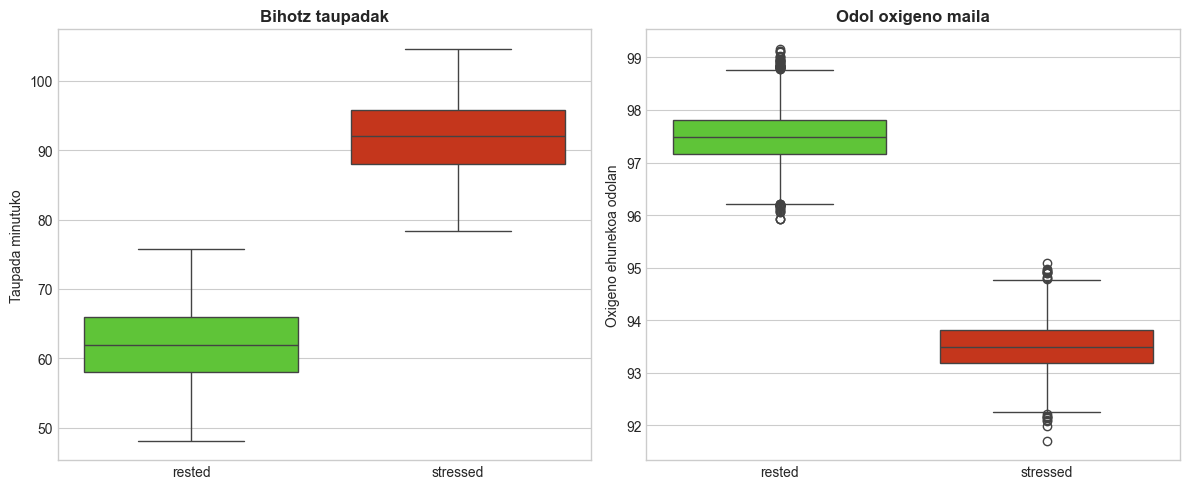

In [263]:
## informazio erabilgarria ematen duen grafika bat

# Ezaugarri fisiologiko nagusiak vs Label (rested/stressed)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bihotz taupadak (heart_rate_bpm)
sns.boxplot(data=df, x='label', y='heart_rate_bpm', ax=axes[0], palette=['#54DB21', '#E02300'])
axes[0].set_title('Bihotz taupadak', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Taupada minutuko')

# Odol oxigeno maila
sns.boxplot(data=df, x='label', y='blood_oxygen_pct', ax=axes[1], palette=['#54DB21', '#E02300'])
axes[1].set_title('Odol oxigeno maila', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Oxigeno ehunekoa odolan')

plt.tight_layout()
plt.savefig('irudiak/ezaugarrien_analisia.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [241]:
## Train test banaketa

df_model = df.drop(columns=['sequence_id', 'timestep']).copy()

y = df_model["label"].values
X = df_model.drop(columns=["label"])

zutabeak = ['activity_level', 'noise_environment', 'skin_temp_profile', 'gsr_state']

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Label encoding, train test banaketa eta gero egin behar da ondo ateratzeko

le_model = LabelEncoder()

encoders = { }
for zut in zutabeak:
    le = LabelEncoder()
    X_train_df[zut] = le.fit_transform(X_train_df[zut])
    X_test_df[zut] = le.transform(X_test_df[zut])
    encoders[zut] = le

X_train = X_train_df.values.astype(np.float32)
X_test = X_test_df.values.astype(np.float32)

## LE klaseetarako

le_y = LabelEncoder()
y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)

## 1. Ariketa: Sare Neuronal Eraketa
Sare Neuronalaren arkitektura jada eginda dago, baina parametroak zuek erabaki behar dituzue.

In [242]:
# Sare Neuronal sinplea
class SNAnomalyDetection(nn.Module):
    def __init__(self, sarrera_size, hidden1_size, hidden2_size, hidden3_size, irteera_size):
        super(SNAnomalyDetection, self).__init__()
        
        # geruzak definitzeko : nn.Linear
        self.hl1 = nn.Linear(
            sarrera_size,
            hidden1_size
        )  # sarrera -> hidden layer 1
        self.hl2 = nn.Linear(
            hidden1_size,
            hidden2_size
        )  # hidden layer 1 -> hidden layer 2
        self.hl3 = nn.Linear(
            hidden2_size,
            hidden3_size
        )  # hidden layer 2 -> hidden layer 3
        self.irteera = nn.Linear(
            hidden3_size,
            irteera_size
        )  # hidden layer 3 -> irteera
        
    def forward(self, x):
        # lehenengo geruza eta relu aplikatu
        x = self.hl1(x)
        x = torch.relu(x)
        # bigarren geruza eta relu aplikatu
        x = self.hl2(x)
        x = torch.relu(x)
        # hirugarren geruza eta relu aplikatu
        x = self.hl3(x)
        x = torch.relu(x)
        # irteera geruza eta sigmoid aplikatu
        x = self.irteera(x)
        x = torch.sigmoid(x)
        
        return x

In [243]:
# Entrenamendu funtzioa
def modeloa_entrenatu(modelo, X_train, y_train, X_test, y_test, 
                    epochs=48, learning_rate=0.01):
    """
    SN modelo entrenamendu metodoa
    
    Parametroak:
    - modelo: nn.Module ko isntantzia klasea
    - X_train, y_train: Entrenamendu datuak eta klaseak
    - X_test, y_test: Test datuak eta klaseak
    - epochs: epoka kopurua
    - learning_rate: Ikasketa tasa
    """
    
    # Errore funtzioa ezarri
    criterio = nn.BCELoss()
    
    # Pisuak birkalkulatzeko algoritmoa 
    optimizador = optim.Adam(modelo.parameters(), lr=learning_rate)
    
    # Historikoak
    train_losses = []
    test_losses = []
    
    print("Entrenamendua hasieratzen...")
    print("=" * 50)
    
    for epoch in range(epochs):
        # ==================== TRAINING ====================
        modelo.train()  # modeloa entrenamendu egoera jarri
        
        # Forward pass
        y_pred_train = modelo(X_train)
        loss_train = criterio(y_pred_train, y_train)
        
        # Backward pass
        optimizador.zero_grad()  # Aurreko gradienteak garbitu
        loss_train.backward()     # gradienteak garbitu
        optimizador.step()        # pisuak eguneratu
        
        # ==================== ERRORE EBALUAZIOA ====================
        modelo.eval()  # modeloa ebaluazio egoeran jarri (ikasi ez dezan)
        
        with torch.no_grad():  # EZIN DIRA GRADIENTEAK TESTEAN KALKULATU
            y_pred_test = modelo(X_test)
            loss_test = criterio(y_pred_test, y_test)
        
        train_losses.append(loss_train.item())
        test_losses.append(loss_test.item())
        
        # 10 epokako eboluzioa erakutsi
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {loss_train.item():.4f} | "
                  f"Test Loss: {loss_test.item():.4f}")
    
    print("=" * 50)
    print("Entrenamendua bukatuta!")
    
    return train_losses, test_losses, y_pred_test

Entrenamendua hasieratzen...
Epoka  10/30 | Train Loss: 0.2632 | Test Loss: 0.2077
Epoka  20/30 | Train Loss: 0.0163 | Test Loss: 0.0096
Epoka  30/30 | Train Loss: 0.0012 | Test Loss: 0.0008
Entrenamendua bukatuta!
Epoka  20/30 | Train Loss: 0.0163 | Test Loss: 0.0096
Epoka  30/30 | Train Loss: 0.0012 | Test Loss: 0.0008
Entrenamendua bukatuta!


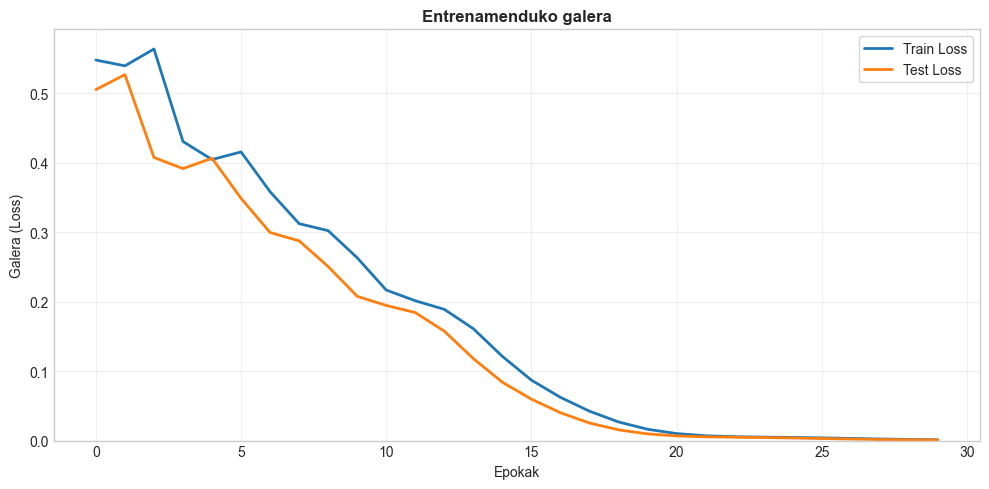

In [244]:
## Modeloa entrenatu
# kargatu
modelo = SNAnomalyDetection(sarrera_size=X_train.shape[1], hidden1_size=32, hidden2_size=16, hidden3_size=8, irteera_size=1)
# entrenatu 100 epokatan

# Aldatu X_train, y_train, X_test, y_test tentsore izateko, PyToerch lan egin ahal izateko
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) 
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
train_losses, test_losses, y_pred_test = modeloa_entrenatu(
    modelo, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    epochs=30, learning_rate=0.01
)

# Errore galera grafika
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epokak')
plt.ylabel('Galera (Loss)')
plt.ylim(bottom=0)
plt.title('Entrenamenduko galera', fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.1. Ariketa: Sare Neuronal Ebaluazioa
- Overfitting al dago?

    Ikusten denez ez dago overfittinga. Grafikoan ikus dezake nola Train Loss eta Test Loss biak batera beherantz doazela, eta azkenaldian, ia 0ra ailegatzen dira.
    
- Sailkapena denez, nolakoa da nahasmen-matrizea?

    Hemen nahasmen-matrizea:

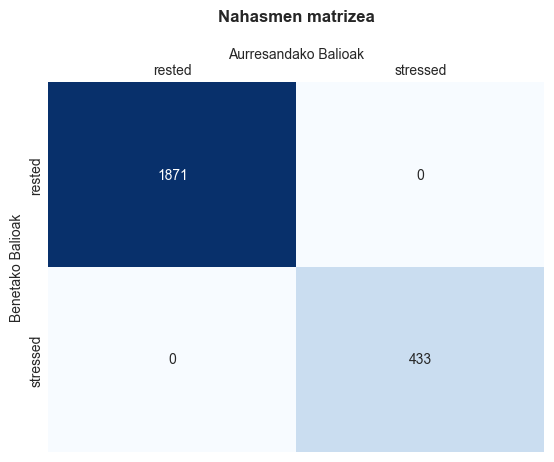


F1 Score (macro): 1.0000
F1 Score (micro): 1.0000
Accuracy: 1.0000


In [252]:
## modelo ebaluazioa

# PyTorch tentsorea numpy array bihurtu
y_pred = (y_pred_test.numpy() > 0.5).astype(int).flatten()

cm_pca = confusion_matrix(y_test, y_pred)

# Erakutsi matrizea 
ax2 = sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap='Blues',
    cbar=False,
)

ax2.set_title('Nahasmen matrizea\n', fontweight="bold")

ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')

ax2.set_xlabel('Aurresandako Balioak')
ax2.set_ylabel('Benetako Balioak')

ax2.xaxis.set_ticklabels(['rested', 'stressed'])
ax2.yaxis.set_ticklabels(['rested', 'stressed'])

plt.show()

# F1 
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')

# Accuracy
accuracy = (y_pred == y_test).mean()

print(f"\nF1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"Accuracy: {accuracy:.4f}")

#### Nahasmen-matrizea
Ikusten dugunez, test egiterako orduan klase guztiak asmatu ditu.

## 2. Ariketa: Beste algoritmo batekin konparazioa

Nahiz eta sare neuronalek emaitza oso onak eman, beste algoritmoek zer nolako emaitzak ematen duten ikusi behar da. Adibidez; iragarpen berriak kalkulatzeko denbora, accuracy emaitza hobeak, ...

In [246]:
## 2. Ariketa: Erabaki Zuhaitza (Decision Tree)

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score

# Modeloa sortu eta entrenatu
clf = tree.DecisionTreeClassifier(random_state=42)
clf = clf.fit(X_train, y_train)

# Iragarpenak egin
predicted_values = clf.predict(X_test)
predicted_values

array([0, 1, 0, ..., 0, 0, 1], shape=(2304,))


F1 Score (macro) decision tree: 1.0000
F1 Score (micro) decision tree: 1.0000
Accuracy decision tree: 0.9996


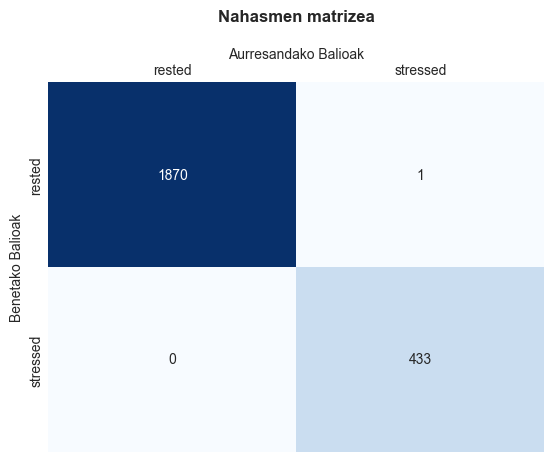

In [251]:
# Nahasmen matrizea

# nahasmen matrizea kalkulatu
cm_dt = confusion_matrix(y_test, predicted_values)

# Erakutsi matrizea
ax2 = sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap='Blues',
    cbar=False,
)

ax2.set_title('Nahasmen matrizea\n', fontweight="bold")

ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')

ax2.set_xlabel('Aurresandako Balioak')
ax2.set_ylabel('Benetako Balioak')

ax2.xaxis.set_ticklabels(['rested', 'stressed'])
ax2.yaxis.set_ticklabels(['rested', 'stressed'])

# F1 
f1_macro_dt = f1_score(y_test, y_pred, average='macro')
f1_micro_dt = f1_score(y_test, y_pred, average='micro')

# Accuracy
accuracy_dt = accuracy_score(y_test, predicted_values)

print(f"\nF1 Score (macro) decision tree: {f1_macro_dt:.4f}")
print(f"F1 Score (micro) decision tree: {f1_macro_dt:.4f}")
print(f"Accuracy decision tree: {accuracy_dt:.4f}")

plt.show()

In [ ]:
# Konparaketa: Sare Neuronala vs Erabaki Zuhaitza

print("KONPARAKETA:")
print(f"Sare Neuronal Accuracy: {accuracy:.4f}")
print(f"Erabaki Zuhaitza Accuracy: {accuracy_dt:.4f}")
print(f"Desberdintasuna: {accuracy - accuracy_dt:.4f}")

KONPARAKETA:
Sare Neuronal Accuracy: 1.0000
Erabaki Zuhaitza Accuracy: 0.9996
Desberdintasuna: 0.0004


# 3. Ondorioak

Smart erlojuen datuekin estres maila sailkatzeko bi eredu sortu ditut: Sare Neuronala eta Erabaki Zuhaitza.

### Egindakoa labur

**Datu azterketa**: Ikusi dut datu askok zenbakizkoak zirela, bakarrik 5 zutabe Label Encoderen bidez zenbakietara pasatu izan behar ditut. Bihotz taupadak eta odol oxigeno maila ezaugarri oso garrantzitsuak dira estres maila determinatzeko.

**Sare Neuronala**: 3 geruza ezkutu sortu ditut (32, 16 eta 8 neurona). Aktibazio funtzio bezala ReLU erabili dut geruza ezkutuetan eta Sigmoid irteeran, klase bikoitzeko sailkapena delako. 30 epoka entrenatu dut galera txikia lortuz.

**Erabaki Zuhaitza**: Konparatzeko, erabaki zuhaitz sinple bat entrenatu dut. Azkarragoa da, eta kasu hontenan ia emaitza berberak ematen ditu.

### Emaitzak

Bi modeloek emaitza onak eman dituzte. Sare Neuronalak F1 puntuazio altua lortu du, eta erabaki zuhaitzak ere ondo sailkatzen du. Nahasmen matrizeetan ikus daiteke nola sailkatzen diren bi kasuak.

### Zer ikasi dut

- Sare neuronalek konplexitatea onartzen dute baina denbora gehiago behar dute eraikitzeko eta entrenatzeko. 
- Erabaki zuhaitzak azkarragoak dira eta interpretatzeko errazagoak. 
- Datuak ondo prestatzea (label encoding, train/test banaketa) oso garrantzitsua da .
- Overfitting-arekin kontuz ibili behar da, baina kasu honetan ez da gertatu.

Laburtzeko, bi ereduak erabilgarriak dira. Sare Neuronalak zehaztasun gehiago eman dezake datu konplexuetan, baina erabaki zuhaitza azkarragoa da, horregatik kasu honetarako metodo onena niretzat erabaki zuhaitza da.